# Optional Project - Colab muP Attention Scale Ablation

Runs the ablation for Part 3: keep the muP optimizer/base-shape/readout setup fixed, and compare tiny/small models with attention scale `1/head_dim` versus the standard PyTorch attention scale `1/sqrt(head_dim)`. Re-run interrupted training cells to resume from Google Drive checkpoints.

In [1]:
# ===== User config =====
REPO_URL = "https://github.com/Peng-y-x/optionalproject.git"
REPO_DIR = "/content/optionalproject"
REPO_BRANCH = "run"

ABLATION_CONFIG = "configs/mup_attention_scale_ablation.yaml"
MUP_BEST_LR_JSON = "outputs/part3_mup_lr_sweep/best_lr.json"
DRIVE_MUP_BEST_LR_JSON = "/content/drive/MyDrive/svg-scaling/part3_mup_lr_sweep/best_lr.json"

DRIVE_ROOT = "/content/drive/MyDrive/svg-scaling"
ABLATION_RUN_DIR = "part3_attention_scale_ablation"
ABLATION_ANALYSIS_DIR = "part3_attention_scale_ablation_analysis"

# Set to None to use the LR from MUP_BEST_LR_JSON if available, otherwise config default.
LEARNING_RATE_OVERRIDE = None


In [2]:
# 1) Clone repo and checkout branch
import os
if not os.path.exists(REPO_DIR):
    !git clone --branch {REPO_BRANCH} --single-branch {REPO_URL} {REPO_DIR}
else:
    print('Repo already exists:', REPO_DIR)
%cd $REPO_DIR
!git fetch origin
!git checkout {REPO_BRANCH}
!git pull origin {REPO_BRANCH}
!git branch --show-current
!git rev-parse --short HEAD


Cloning into '/content/optionalproject'...
remote: Enumerating objects: 194, done.
remote: Counting objects: 100% (194/194), done.
remote: Compressing objects: 100% (132/132), done.
remote: Total 194 (delta 110), reused 142 (delta 58), pack-reused 0 (from 0)
Receiving objects: 100% (194/194), 277.57 KiB | 2.95 MiB/s, done.
Resolving deltas: 100% (110/110), done.
/content/optionalproject
Already on 'run'
Your branch is up to date with 'origin/run'.
From https://github.com/Peng-y-x/optionalproject
 * branch            run        -> FETCH_HEAD
Already up to date.
run
40703c6


In [3]:
# 2) Mount Google Drive for resumable ablation checkpoints and outputs
from google.colab import drive
drive.mount('/content/drive')
!mkdir -p {DRIVE_ROOT}/{ABLATION_RUN_DIR}
!mkdir -p {DRIVE_ROOT}/{ABLATION_ANALYSIS_DIR}


Mounted at /content/drive


In [4]:
# 3) Install system + Python dependencies
!apt-get update -y
!apt-get install -y libcairo2 libcairo2-dev libffi-dev
!python -m pip install --upgrade pip
!pip install -r requirements.txt


Get:1 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease [3,632 B]
Get:2 https://cli.github.com/packages stable InRelease [3,917 B]
Get:3 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2204/x86_64  InRelease [1,581 B]
Get:4 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ Packages [89.0 kB]
Get:5 https://cli.github.com/packages stable/main amd64 Packages [356 B]       
Get:6 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2204/x86_64  Packages [2,594 kB]
Hit:7 http://archive.ubuntu.com/ubuntu jammy InRelease                         
Get:8 http://security.ubuntu.com/ubuntu jammy-security InRelease [129 kB]      
Get:9 http://archive.ubuntu.com/ubuntu jammy-updates InRelease [128 kB]        
Get:10 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease [18.1 kB]
Get:11 https://r2u.stat.illinois.edu/ubuntu jammy InRelease [6,555 B]          
Hit:12 https://ppa.launchpadcontent.net/graphics-drivers/ppa/ubuntu jammy 

In [ ]:
# 4) HF auth from Colab Keys (key name must be HF_TOKEN)
import os
from google.colab import userdata
token = userdata.get('HF_TOKEN')
if token:
    os.environ['HF_TOKEN'] = token
    print('HF token loaded from Colab key.')
else:
    print('HF token not found in Colab key HF_TOKEN. Public dataset loading may still work.')
print('has_hf_token:', bool(os.getenv('HF_TOKEN')))


In [6]:
# 5) GPU sanity check
import torch
print('torch', torch.__version__)
print('cuda_available', torch.cuda.is_available())
if torch.cuda.is_available():
    print('gpu', torch.cuda.get_device_name(0))
    print('bf16_supported', torch.cuda.is_bf16_supported())


torch 2.10.0+cu128
cuda_available True
gpu NVIDIA A100-SXM4-80GB
bf16_supported True


In [7]:
# 6) Reuse the Part 3 selected muP LR if it exists on Drive
import json, shutil
from pathlib import Path

if not Path(MUP_BEST_LR_JSON).exists() and Path(DRIVE_MUP_BEST_LR_JSON).exists():
    Path(MUP_BEST_LR_JSON).parent.mkdir(parents=True, exist_ok=True)
    shutil.copy2(DRIVE_MUP_BEST_LR_JSON, MUP_BEST_LR_JSON)

BEST_LR_ARG = ''
LR_ARG = ''
if LEARNING_RATE_OVERRIDE is not None:
    LR_ARG = f'--learning-rate {LEARNING_RATE_OVERRIDE}'
elif Path(MUP_BEST_LR_JSON).exists():
    best = json.loads(Path(MUP_BEST_LR_JSON).read_text())
    print(json.dumps(best, indent=2))
    BEST_LR_ARG = f'--best-lr-json {MUP_BEST_LR_JSON}'
else:
    print('No Part 3 best LR JSON found; using the ablation config default learning_rate.')

print('BEST_LR_ARG=', BEST_LR_ARG)
print('LR_ARG=', LR_ARG)


{
  "learning_rate": 0.004,
  "val_loss": 0.7586738941988432,
  "val_ppl": 2.135442519305405,
  "val_tokens": 1006621.0,
  "run_name": "tiny_mup_lr_4.0e-03",
  "global_step": 14612,
  "tokens_seen": 100470493,
  "num_parameters": 1579776,
  "num_parameters_non_embedding": 1055488,
  "wall_clock_seconds": 331.82196068763733,
  "tokens_per_second_epoch": 302784.33890208526,
  "peak_gpu_memory_gb": 1.3334436416625977
}
BEST_LR_ARG= --best-lr-json outputs/part3_mup_lr_sweep/best_lr.json
LR_ARG= 


## Optional Smoke Test

For a quick wiring check, temporarily uncomment `max_train_tokens` and `max_eval_tokens` in `configs/mup_attention_scale_ablation.yaml`. For final results, leave them commented so each run uses the same one-epoch protocol as Part 3.

In [8]:
# 7) Run tiny/small ablation
# If Colab disconnects, rerun this cell; each run resumes from Drive latest.pt.
%cd $REPO_DIR
!python scripts/run_mup_attention_scale_ablation.py \
  --config {ABLATION_CONFIG} \
  {BEST_LR_ARG} \
  {LR_ARG}


/content/optionalproject
[attention-scale-ablation] config=configs/mup_tiny.yaml scale=mup lr=0.004 run=tiny_mup_attn_mup
/content/optionalproject/src/train/trainer.py:457: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  self.scaler = torch.cuda.amp.GradScaler(enabled=self.device.type == "cuda" and self.precision == "fp16")
README.md: 100% 654/654 [00:00<00:00, 3.09MB/s]
data/train-00000-of-00001.parquet: 100% 410M/410M [00:02<00:00, 169MB/s] 
data/validation-00000-of-00001.parquet: 100% 4.11M/4.11M [00:00<00:00, 6.71MB/s]
data/test-00000-of-00001.parquet: 100% 4.25M/4.25M [00:00<00:00, 10.3MB/s]
Generating train split: 100% 155571/155571 [00:02<00:00, 74858.38 examples/s]
Generating validation split: 100% 1595/1595 [00:00<00:00, 93603.21 examples/s]
Generating test split: 100% 1590/1590 [00:00<00:00, 90458.24 examples/s]
{"type": "train", "step": 20, "tokens_seen": 140138, "next_row_index": 214, "train_lo

,source_config,attention_scale,learning_rate,num_parameters,val_loss,val_ppl,tokens_seen
0,configs/mup_tiny.yaml,mup,0.004,1579776,0.756645,2.131114,100470493
1,configs/mup_tiny.yaml,sp,0.004,1579776,0.730990,2.077136,100470493
2,configs/mup_small.yaml,mup,0.004,3849216,0.654189,1.923581,100470493
3,configs/mup_small.yaml,sp,0.004,3849216,0.618431,1.856014,100470493


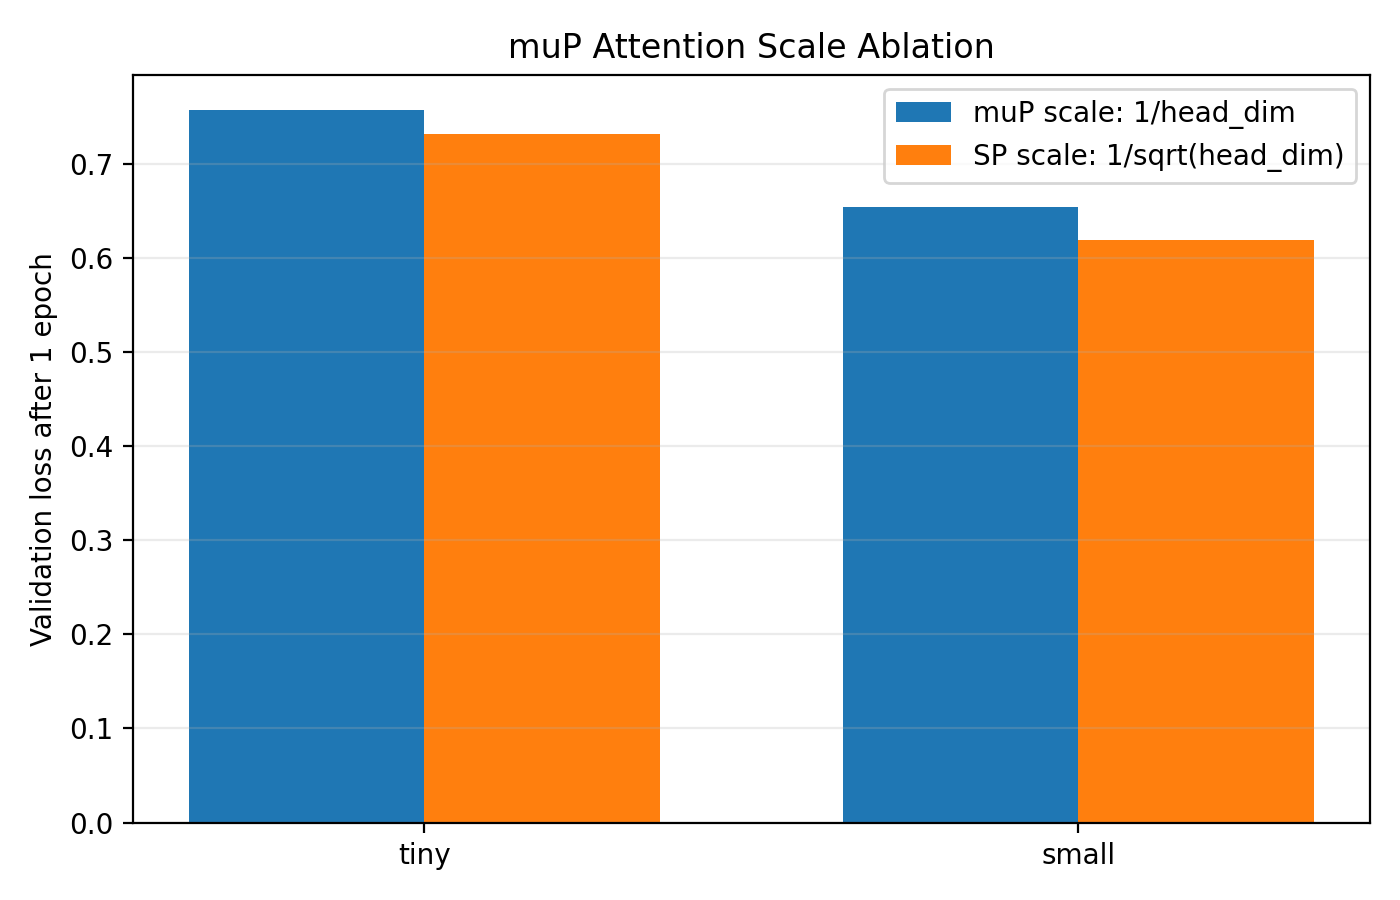

In [9]:
# 8) Inspect ablation results
import pandas as pd
from pathlib import Path
from IPython.display import display, Image

analysis_dir = Path('outputs/part3_attention_scale_ablation_analysis')
csv_path = analysis_dir / 'attention_scale_ablation.csv'
png_path = analysis_dir / 'attention_scale_ablation.png'

df = pd.read_csv(csv_path)
display(df[['source_config', 'attention_scale', 'learning_rate', 'num_parameters', 'val_loss', 'val_ppl', 'tokens_seen']])
display(Image(filename=str(png_path)))
